# Metrics comparison between IK control solutions

## Imports 

In [17]:
import ast
import numpy as np
import pandas as pd

# import matplotlib
# matplotlib.use("TkAgg")
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error

In [18]:
test = "heart"  # line, circle, heart

filepath_sym = f"data/sym_{test}_data.csv"
filepath_num = f"data/num_{test}_data.csv"
filepath_qp = f"data/qp_{test}_data.csv"

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-45.699365,20.268327,-2.110257,-71.943844,-4.892438,30.507757,32.685959,-45.699365,-20.268327,2.110257,-71.943844,4.892438,30.507757,-32.685959,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-8.829793013420684e-08, 1.9259936492786662e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.0934805135809356e-06, 1.2327074713834926e..."
1,0.008333,-45.631070,20.417319,-1.974118,-71.878657,-5.099069,30.364675,32.793080,-45.631070,-20.417319,1.974118,-71.878657,5.099069,30.364675,-32.793080,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.587942307090806e-07, 1.9465170048269614e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.1665594594201245e-06, 1.2113836696891434e..."
2,0.016667,-45.569813,20.568503,-1.838041,-71.812144,-5.309354,30.226705,32.901858,-45.569813,-20.568503,1.838041,-71.812144,5.309354,30.226705,-32.901858,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-4.108314249906542e-08, 1.893748377281043e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.0514340787470822e-06, 1.2633796494607578e..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1440 non-null   float64
 1   l_q0         1440 non-null   float64
 2   l_q1         1440 non-null   float64
 3   l_q2         1440 non-null   float64
 4   l_q3         1440 non-null   float64
 5   l_q4         1440 non-null   float64
 6   l_q5         1440 non-null   float64
 7   l_q6         1440 non-null   float64
 8   r_q0         1440 non-null   float64
 9   r_q1         1440 non-null   float64
 10  r_q2         1440 non-null   float64
 11  r_q3         1440 non-null   float64
 12  r_q4         1440 non-null   float64
 13  r_q5         1440 non-null   float64
 14  r_q6         1440 non-null   float64
 15  l_pose       1440 non-null   object 
 16  l_real_pose  1440 non-null   object 
 17  r_pose       1440 non-null   object 
 18  r_real_pose  1440 non-null   object 
dtypes: flo

In [19]:
df_sym = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-47.166548,7.715591,15.077701,-71.943831,-6.980102,32.333060,12.333161,-47.154274,-7.760825,-15.014793,-71.943817,6.974013,32.325195,-12.409106,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[4.0257409700261704e-07, -1.122800035856234e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[1.1453916149983812e-06, 4.274503319923802e-0..."
1,0.008333,-47.137137,7.845570,15.253718,-71.878814,-7.226169,32.265336,12.410303,-47.124760,-7.890560,-15.190515,-71.878910,7.219617,32.257300,-12.486114,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-5.740029040968153e-08, -3.632758448614969e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-6.718839851149738e-08, 1.9298926046665952e-..."
2,0.016667,-47.114870,7.978119,15.429833,-71.812431,-7.473713,32.203837,12.488045,-47.102361,-8.022924,-15.366430,-71.812609,7.466837,32.195572,-12.563763,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[3.588182895253311e-08, -5.374344606449125e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.5592882762760496e-07, 1.4701079670172101e..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1440 non-null   float64
 1   l_q0         1440 non-null   float64
 2   l_q1         1440 non-null   float64
 3   l_q2         1440 non-null   float64
 4   l_q3         1440 non-null   float64
 5   l_q4         1440 non-null   float64
 6   l_q5         1440 non-null   float64
 7   l_q6         1440 non-null   float64
 8   r_q0         1440 non-null   float64
 9   r_q1         1440 non-null   float64
 10  r_q2         1440 non-null   float64
 11  r_q3         1440 non-null   float64
 12  r_q4         1440 non-null   float64
 13  r_q5         1440 non-null   float64
 14  r_q6         1440 non-null   float64
 15  l_pose       1440 non-null   object 
 16  l_real_pose  1440 non-null   object 
 17  r_pose       1440 non-null   object 
 18  r_real_pose  1440 non-null   object 
dtypes: flo

In [20]:
def parse_pose_matrix(matrix):
    """Convert a string of a matrix into a NumPy array."""
    if isinstance(matrix, str):
        return np.array(ast.literal_eval(matrix))
    else:
        return np.array(matrix)

In [21]:
l_pos_errs = []
l_rot_errs = []
r_pos_errs = []
r_rot_errs = []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-47.166548,7.715591,15.077701,-71.943831,-6.980102,32.333060,12.333161,-47.154274,-7.760825,...,32.325195,-12.409106,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[4.0257409700261704e-07, -1.122800035856234e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[1.1453916149983812e-06, 4.274503319923802e-0...",2.417304e-07,4.133434e-07,7.426792e-07,0.000001
1,0.008333,-47.137137,7.845570,15.253718,-71.878814,-7.226169,32.265336,12.410303,-47.124760,-7.890560,...,32.257300,-12.486114,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-5.740029040968153e-08, -3.632758448614969e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-6.718839851149738e-08, 1.9298926046665952e-...",1.797586e-05,3.707929e-07,2.235293e-04,0.000002
2,0.016667,-47.114870,7.978119,15.429833,-71.812431,-7.473713,32.203837,12.488045,-47.102361,-8.022924,...,32.195572,-12.563763,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[3.588182895253311e-08, -5.374344606449125e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.5592882762760496e-07, 1.4701079670172101e...",2.978907e-05,5.437881e-07,1.351687e-04,0.000001


In [22]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_qp.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_qp["l_pos_err"] = l_pos_errs
df_qp["l_rot_err"] = l_rot_errs

df_qp["r_pos_err"] = r_pos_errs
df_qp["r_rot_err"] = r_rot_errs

display(df_num.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-47.166548,7.715591,15.077701,-71.943831,-6.980102,32.333060,12.333161,-47.154274,-7.760825,...,32.325195,-12.409106,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[4.0257409700261704e-07, -1.122800035856234e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[1.1453916149983812e-06, 4.274503319923802e-0...",2.417304e-07,4.133434e-07,7.426792e-07,0.000001
1,0.008333,-47.137137,7.845570,15.253718,-71.878814,-7.226169,32.265336,12.410303,-47.124760,-7.890560,...,32.257300,-12.486114,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-5.740029040968153e-08, -3.632758448614969e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-6.718839851149738e-08, 1.9298926046665952e-...",1.797586e-05,3.707929e-07,2.235293e-04,0.000002
2,0.016667,-47.114870,7.978119,15.429833,-71.812431,-7.473713,32.203837,12.488045,-47.102361,-8.022924,...,32.195572,-12.563763,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[3.588182895253311e-08, -5.374344606449125e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.5592882762760496e-07, 1.4701079670172101e...",2.978907e-05,5.437881e-07,1.351687e-04,0.000001


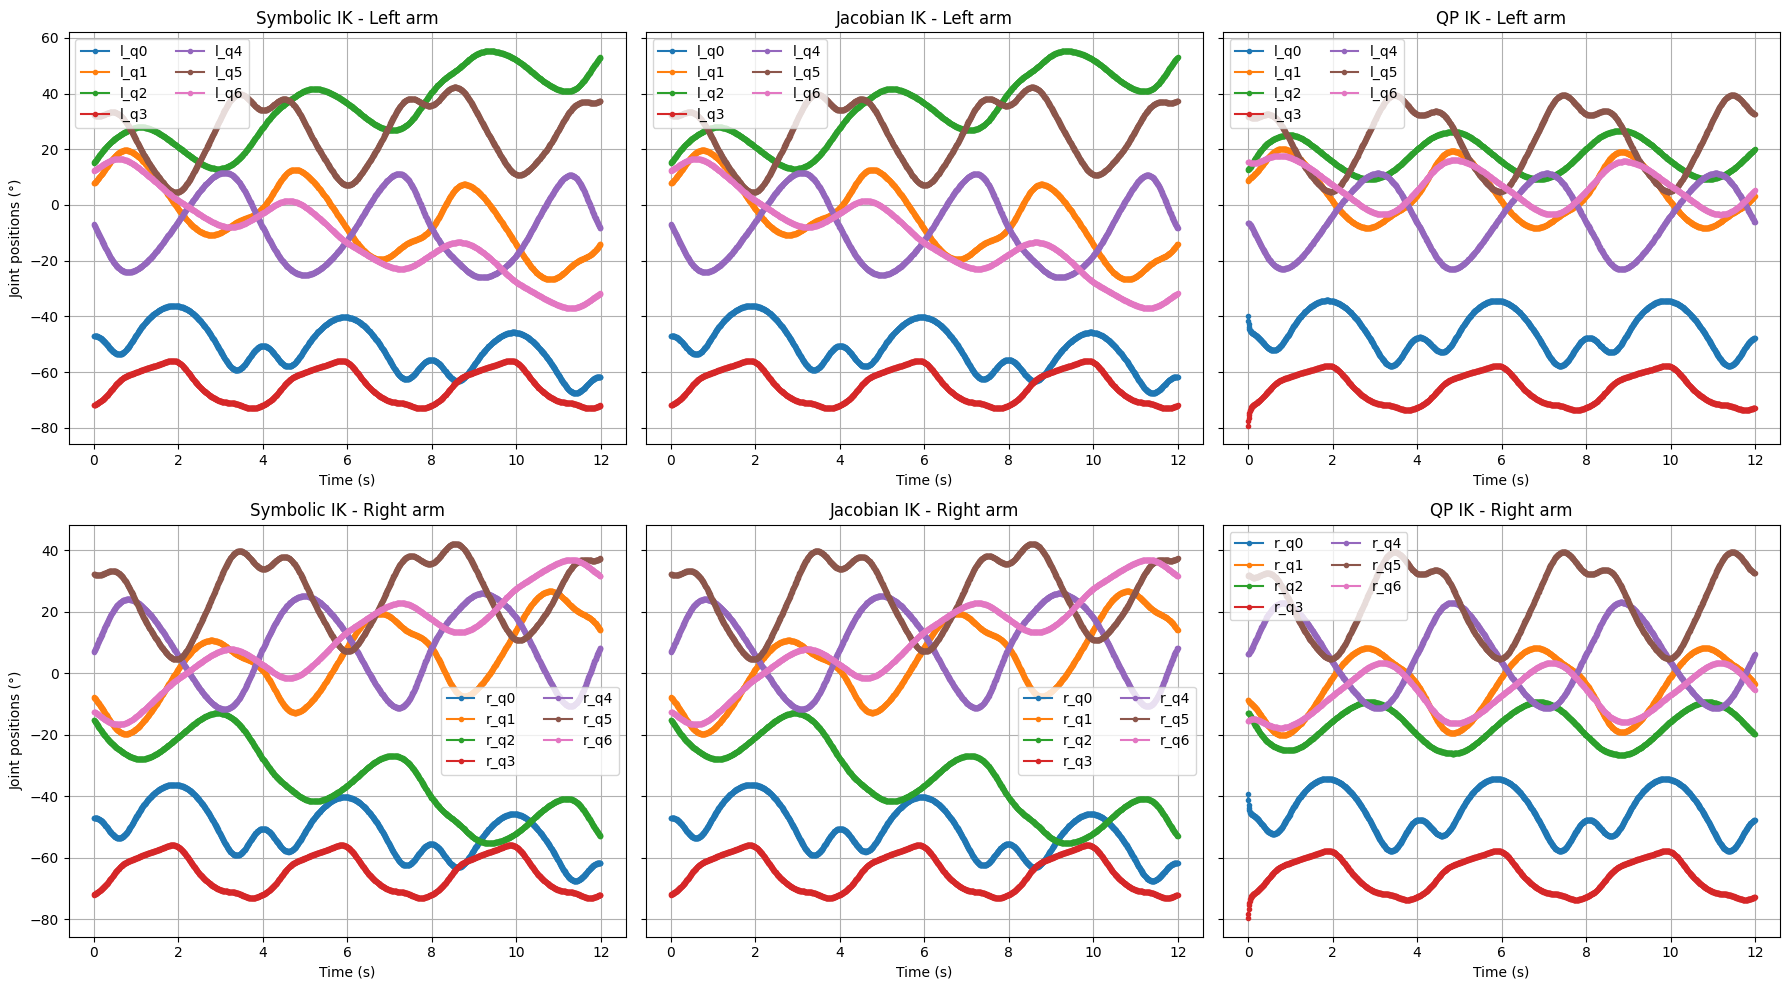

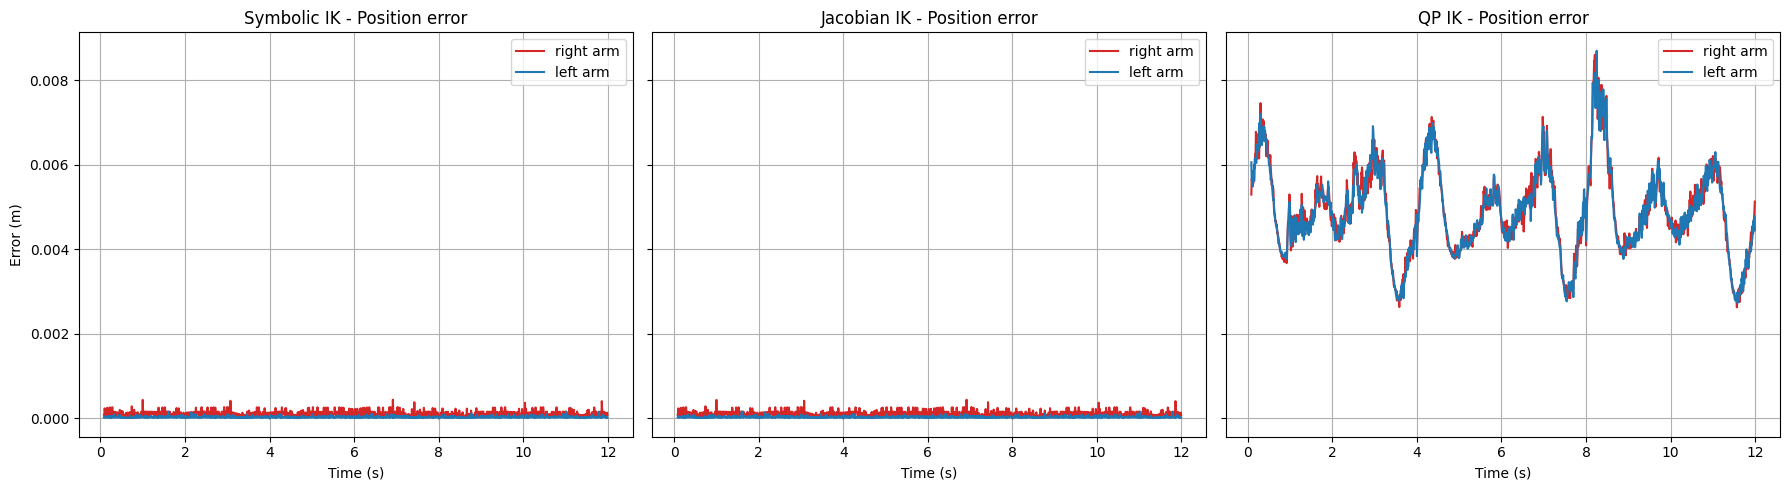

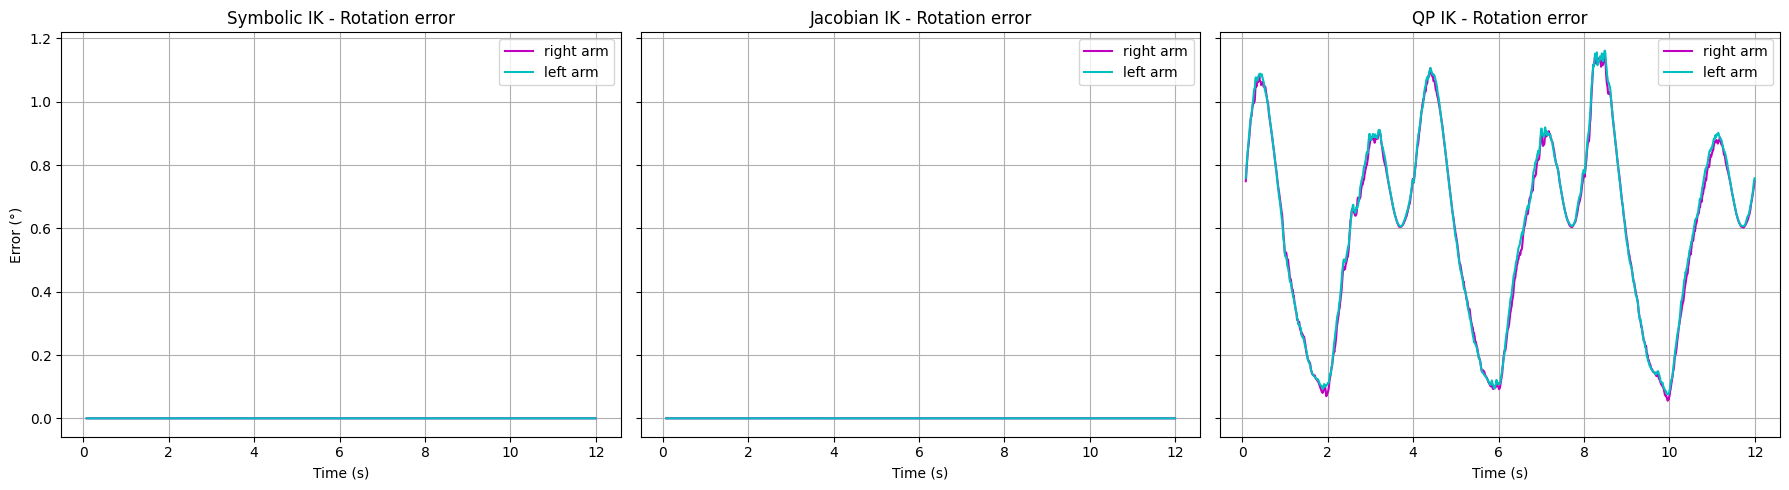

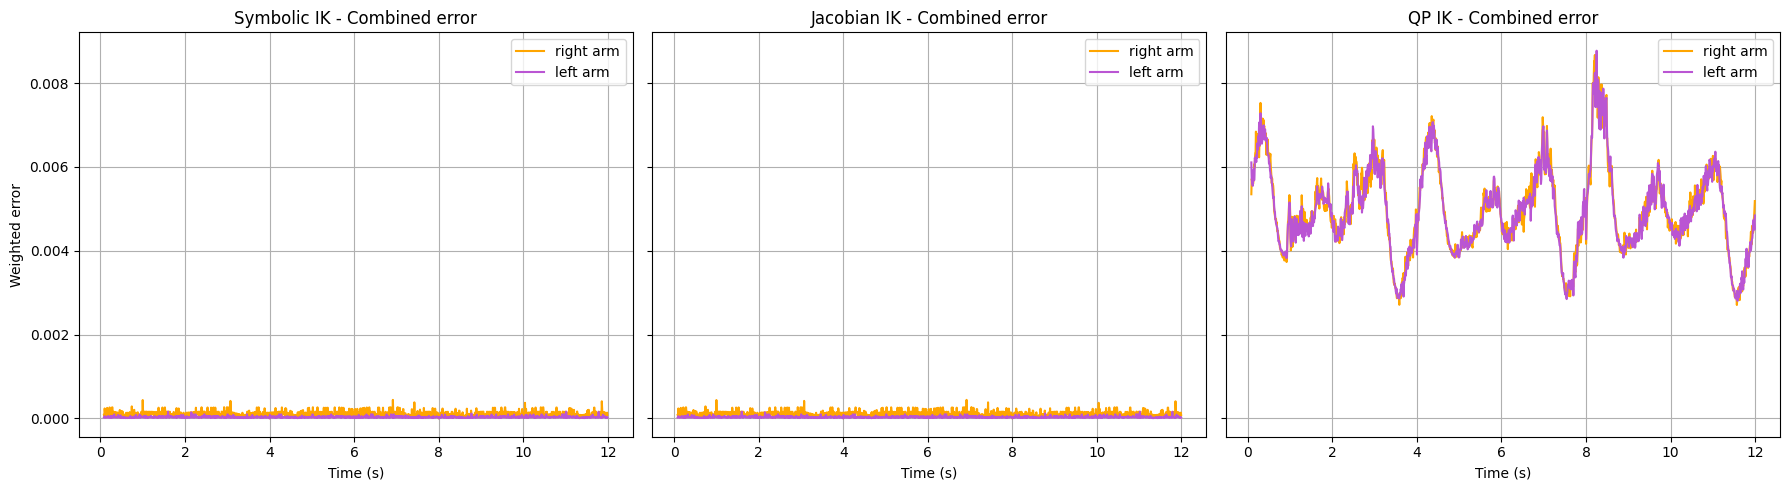

In [23]:
dfs = [(df_sym, "Symbolic IK"), (df_num, "Jacobian IK"), (df_qp, "QP IK")]
l_cols = [f"l_q{i}" for i in range(7)]
r_cols = [f"r_q{i}" for i in range(7)]

time_slice = slice(10, None)
lambda_theta = 1e-6 / np.deg2rad(1) ** 2

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")
for idx, (df, title) in enumerate(dfs):
    for col in l_cols:
        axes[0, idx].plot(df["time"], df[col], marker=".")
    axes[0, idx].set_title(f"{title} - Left arm")
    axes[0, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[0, idx].set_ylabel("Joint positions (°)")
    axes[0, idx].grid(True)
    axes[0, idx].legend(l_cols, ncol=2)

    for col in r_cols:
        axes[1, idx].plot(df["time"], df[col], marker=".")
    axes[1, idx].set_title(f"{title} - Right arm")
    axes[1, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[1, idx].set_ylabel("Joint positions (°)")
    axes[1, idx].grid(True)
    axes[1, idx].legend(r_cols, ncol=2)

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df["time"][time_slice], df["r_pos_err"][time_slice], label="right arm", color="tab:red")
    axes[idx].plot(df["time"][time_slice], df["l_pos_err"][time_slice], label="left arm", color="tab:blue")
    axes[idx].set_title(f"{title} - Position error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (m)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df["time"][time_slice], np.rad2deg(df["r_rot_err"][time_slice]), label="right arm", color="m")
    axes[idx].plot(df["time"][time_slice], np.rad2deg(df["l_rot_err"][time_slice]), label="left arm", color="c")
    axes[idx].set_title(f"{title} - Rotation error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (°)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    comb_l = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
    comb_r = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
    axes[idx].plot(df["time"][time_slice], comb_r[time_slice], label="right arm", color="orange")
    axes[idx].plot(df["time"][time_slice], comb_l[time_slice], label="left arm", color="mediumorchid")
    axes[idx].set_title(f"{title} - Combined error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Weighted error")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

## 3D Trajectories comparison

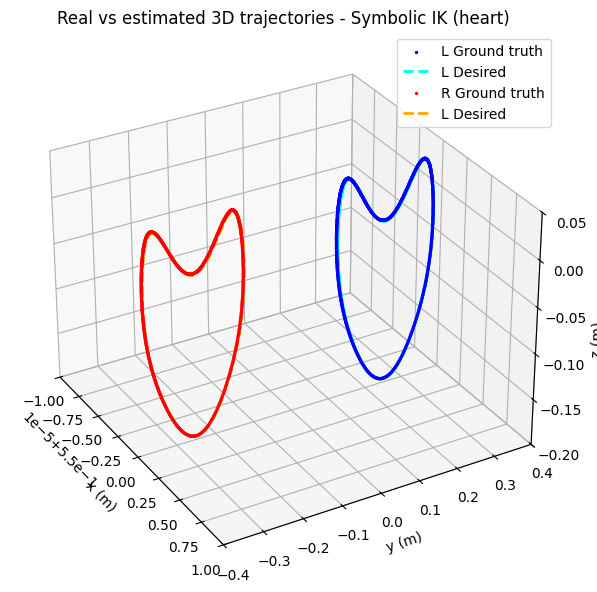

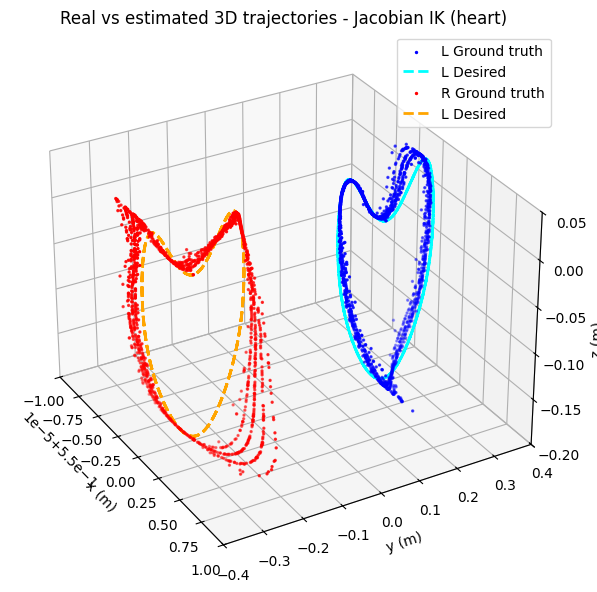

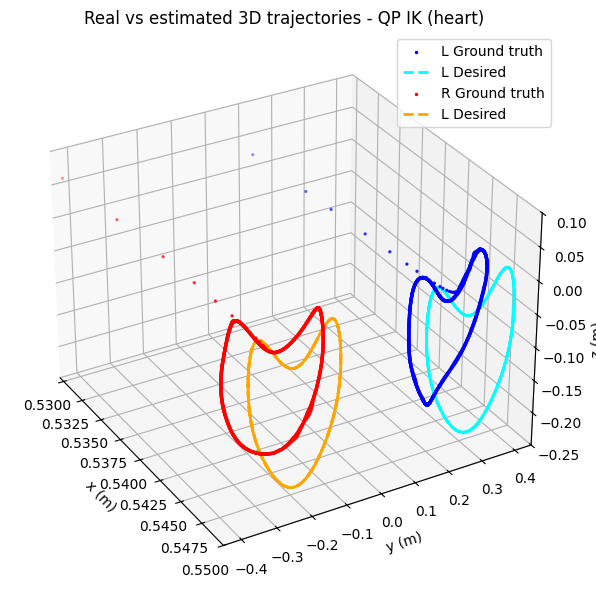

In [24]:
from mpl_toolkits.mplot3d import Axes3D


test = "heart"  # line, circle, heart

filepath_sym = f"data/sym_{test}_data.csv"
filepath_num = f"data/num_{test}_data.csv"
filepath_qp = f"data/qp_{test}_data.csv"

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()


if test == "line":
    elev = 30
    azim = -30
    xlim = [0.39999, 0.40001]
    ylim = [-0.5, 0.5]
    zlim = [-(2e-1 - 3e-7), -(2e-1 + 3e-7)]
elif test == "heart":
    elev = 30
    azim = -30
    xlim = [0.54999, 0.55001]
    ylim = [-0.4, 0.4]
    zlim = [-0.2, 0.05]
elif test == "circle":
    elev = 30
    azim = -30
    xlim = [0.3999, 0.4001]
    ylim = [-0.6, 0.6]
    zlim = [-0.35, -0.06]


def extract_trajectory(df, col_name):
    xs, ys, zs = [], [], []
    for pose_str in df[col_name]:
        pose = parse_pose_matrix(pose_str)
        x, y, z = pose[:3, 3]
        xs.append(x)
        ys.append(y)
        zs.append(z)
    return xs, ys, zs


for name, df in zip(["Symbolic IK", "Jacobian IK", "QP IK"], [df_sym, df_num, df_qp]):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.view_init(elev=elev, azim=azim)

    l_x_gth, l_y_gth, l_z_gth = extract_trajectory(df, "l_real_pose")
    l_x_des, l_y_des, l_z_des = extract_trajectory(df, "l_pose")

    r_x_gth, r_y_gth, r_z_gth = extract_trajectory(df, "r_real_pose")
    r_x_des, r_y_des, r_z_des = extract_trajectory(df, "r_pose")

    ax.scatter(l_x_gth, l_y_gth, l_z_gth, label="L Ground truth", color="blue", s=2)
    ax.plot(l_x_des, l_y_des, l_z_des, label="L Desired", linestyle="--", color="cyan", linewidth=2)

    ax.scatter(r_x_gth, r_y_gth, r_z_gth, label="R Ground truth", color="red", s=2)
    ax.plot(r_x_des, r_y_des, r_z_des, label="L Desired", linestyle="--", color="orange", linewidth=2)

    ax.set_title(f"Real vs estimated 3D trajectories - {name} ({test})")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    if name == "QP IK":
        if test == "line":
            ax.set_xlim(0.3995, 0.4005)
            ax.set_ylim(-0.55, 0.55)
            ax.set_zlim(-0.205, -0.195)
        elif test == "heart":
            ax.set_xlim(0.5295, 0.55)
            ax.set_ylim(-0.45, 0.45)
            ax.set_zlim(-0.25, 0.1)
        elif test == "circle":
            ax.set_xlim(0.385, 0.415)
            ax.set_ylim(-0.65, 0.65)
            ax.set_zlim(-0.4, -0.05)
    else:
        ax.set_xlim(xlim[0], xlim[1])
        ax.set_ylim(ylim[0], ylim[1])
        ax.set_zlim(zlim[0], zlim[1])

    ax.legend()
    plt.tight_layout()
    ax.grid(True)
    plt.show()